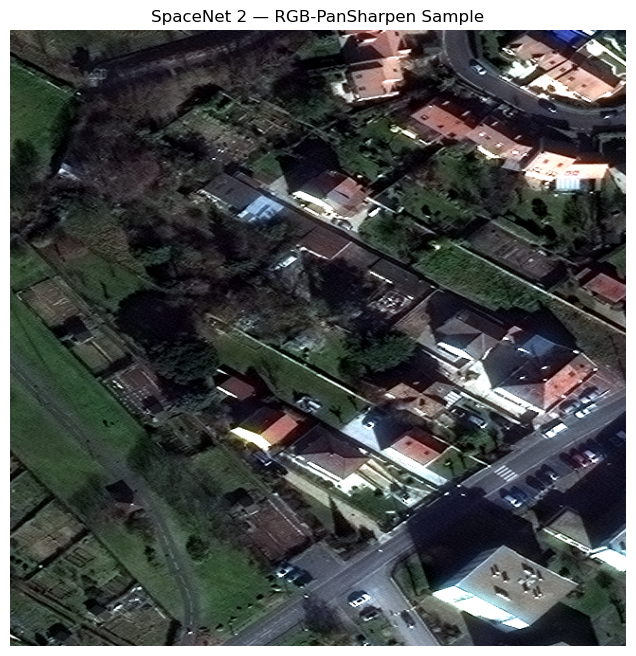

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import tifffile
import numpy as np

ROOT = Path.cwd()

if ROOT.name.lower() == "notebooks":
    ROOT = ROOT.parent

image_path = (
    ROOT
    / "AOI_3_Paris_Train"
    / "RGB-PanSharpen"
    / "RGB-PanSharpen_AOI_3_Paris_img100.tif"
)

image = tifffile.imread(image_path)

# Convert uint16 → displayable RGB
image_display = image.astype(np.float32)

# Percentile stretch for visualization
for c in range(3):
    low = np.percentile(image_display[:, :, c], 2)
    high = np.percentile(image_display[:, :, c], 98)

    image_display[:, :, c] = np.clip(
        (image_display[:, :, c] - low) /
        (high - low + 1e-8),
        0,
        1
    )

plt.figure(figsize=(8, 8))
plt.imshow(image_display)
plt.title("SpaceNet 2 — RGB-PanSharpen Sample")
plt.axis("off")
plt.show()

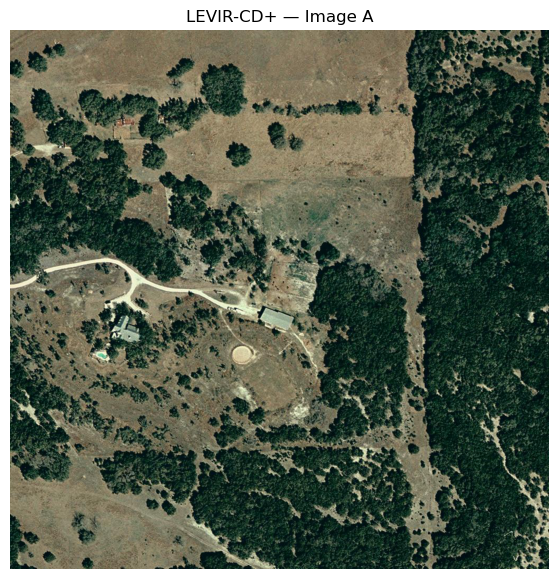

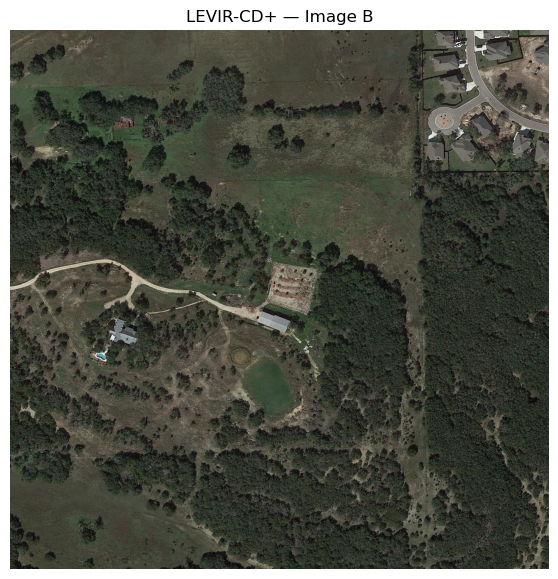

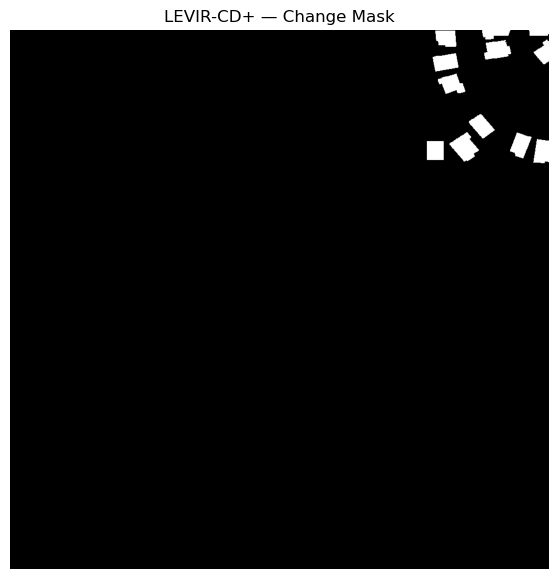

In [2]:
from PIL import Image
import matplotlib.pyplot as plt

ROOT = Path.cwd()

if ROOT.name.lower() == "notebooks":
    ROOT = ROOT.parent

base = ROOT / "LEVIR-CD+" / "train"

A = Image.open(base / "A" / "train_1.png")
B = Image.open(base / "B" / "train_1.png")
label = Image.open(base / "label" / "train_1.png")

plt.figure(figsize=(7, 7))
plt.imshow(A)
plt.title("LEVIR-CD+ — Image A")
plt.axis("off")
plt.show()

plt.figure(figsize=(7, 7))
plt.imshow(B)
plt.title("LEVIR-CD+ — Image B")
plt.axis("off")
plt.show()

plt.figure(figsize=(7, 7))
plt.imshow(label, cmap="gray")
plt.title("LEVIR-CD+ — Change Mask")
plt.axis("off")
plt.show()

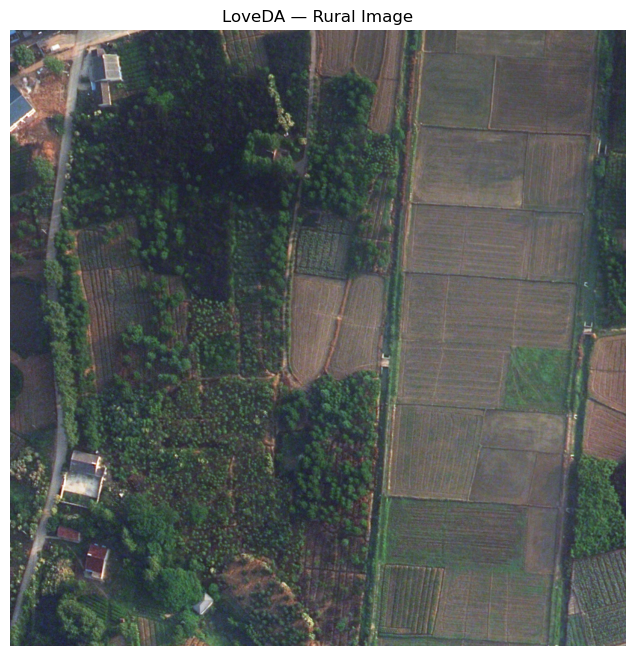

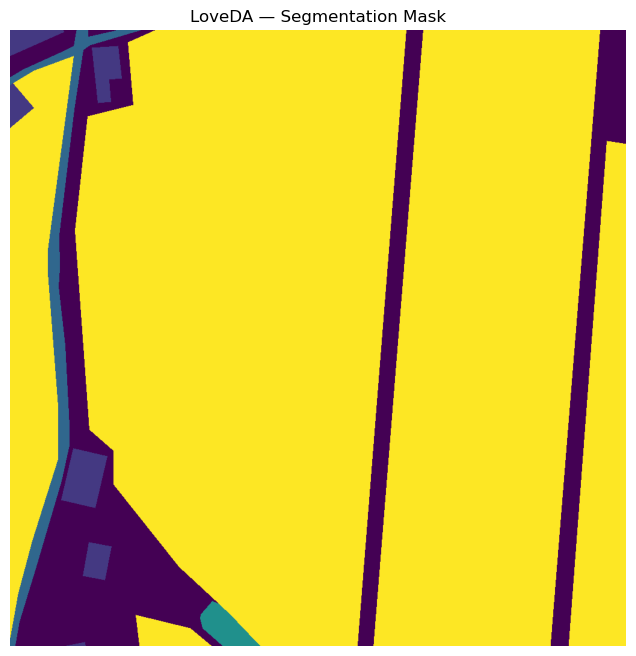

Image shape: (1024, 1024, 3)
Mask shape: (1024, 1024)
Mask classes: [1 2 3 4 7]


In [3]:
image = Image.open(
    ROOT / "Train" / "Rural" / "images_png" / "0.png"
)

mask = Image.open(
    ROOT / "Train" / "Rural" / "masks_png" / "0.png"
)

plt.figure(figsize=(8, 8))
plt.imshow(image)
plt.title("LoveDA — Rural Image")
plt.axis("off")
plt.show()

plt.figure(figsize=(8, 8))
plt.imshow(mask)
plt.title("LoveDA — Segmentation Mask")
plt.axis("off")
plt.show()

print("Image shape:", np.array(image).shape)
print("Mask shape:", np.array(mask).shape)
print("Mask classes:", np.unique(np.array(mask)))

In [4]:
print("=" * 70)
print("URBANWATCH DATASET STATUS")
print("=" * 70)

print("""
SpaceNet 2
-----------
Images:              1,148
Non-empty labels:      633
YOLO train images:     919
YOLO validation:       229
Training boxes:     12,980
Validation boxes:    3,402

YOLO RESULTS
------------
Precision:            0.8274
Recall:               0.7516
mAP@50:               0.8212
mAP@50-95:            0.5004

LEVIR-CD+
-----------
Train: A + B + label
Test:  A + B + label
Image: 1024 × 1024 RGB
Mask:  0 / 255

LoveDA
-----------
Train: images + masks
Val:   images + masks
Test:  images only
Image: 1024 × 1024 RGB
Classes observed: 1, 2, 3, 4, 7
""")

URBANWATCH DATASET STATUS

SpaceNet 2
-----------
Images:              1,148
Non-empty labels:      633
YOLO train images:     919
YOLO validation:       229
Training boxes:     12,980
Validation boxes:    3,402

YOLO RESULTS
------------
Precision:            0.8274
Recall:               0.7516
mAP@50:               0.8212
mAP@50-95:            0.5004

LEVIR-CD+
-----------
Train: A + B + label
Test:  A + B + label
Image: 1024 × 1024 RGB
Mask:  0 / 255

LoveDA
-----------
Train: images + masks
Val:   images + masks
Test:  images only
Image: 1024 × 1024 RGB
Classes observed: 1, 2, 3, 4, 7

